<a href="https://colab.research.google.com/github/Michel1412/Aulas_de_IA/blob/main/Trabalho_michas_Arvore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

# URL dos dados
url = "https://docs.google.com/spreadsheets/d/1g1aQ61vijh6uHJuc8sijeBEMsoIQ2a5yLwUK04Wptlg/export?format=csv"

# Carregar dados
df = pd.read_csv(url)

# Mapeamento para nomes simples e sem espaços
mapping = {
    "Carimbo de data/hora": "timestamp",
    "Você ficou gripado no ano passado ?": "gripe_ano_passado",
    "Você tomou vacina da gripe no ano passado?": "vacina",
    "  Você frequentou no ano passado,  semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.)  ": "ambientes_cheios",
    "  Você viajou no ano passado mais de 100 km de distância?  ": "viajou",
    "  Você tem alergia nas vias aéreas (rinite, sinusite, etc.)?  ": "alergia",
    "Quantas horas você dormiu em média por noite no ano passado?": "horas_sono",
    "Você praticou atividade física no ano passado?": "exercicio",
    "Você se alimentou de forma balanceada no ano passado?": "alimentacao",
    "Em média, quantas vezes você lavou as mãos por dia no ano passado?": "lavagem_maos",
    "Na sua percepção, o seu nível de estresse no ano passado foi:": "estresse"
}

# Renomear e limpar
df_cleaned = df.rename(columns=mapping).dropna()

print("Dados carregados e colunas renomeadas:")
display(df_cleaned.head())

Dados carregados e colunas renomeadas:


,timestamp,gripe_ano_passado,vacina,ambientes_cheios,viajou,alergia,horas_sono,exercicio,alimentacao,lavagem_maos,estresse
0,24/03/2026 15:01:35,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,5.0
1,24/03/2026 15:04:20,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,3.0
2,24/03/2026 15:04:20,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,3.0
3,24/03/2026 15:04:37,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,2.0
4,24/03/2026 15:05:27,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,4.0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# Assuming 'gripe_ano_passado' is the target variable

# --- BEGIN MODIFICATION ---
# List of all available feature columns (excluding 'timestamp' and the target variable itself)
all_possible_features = df_cleaned.drop(columns=['timestamp', 'gripe_ano_passado']).columns.tolist()

# You can modify this list to select specific features for training
# For example: selected_features = ['vacina', 'estresse', 'horas_sono']
selected_features = all_possible_features # By default, use all possible features

X = df_cleaned[selected_features]
y = df_cleaned['gripe_ano_passado']
# --- END MODIFICATION ---

# Convert 'Sim'/'Não' in target to 1/0 for easier modeling
y = y.map({'Sim': 1, 'Não': 0})

# Identify categorical and numerical columns for one-hot encoding and scaling
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Features after one-hot encoding:")
display(X_encoded.head())

Features after one-hot encoding:


,estresse,vacina_Sim,ambientes_cheios_Sim,viajou_Pelo menos uma vez por mês,viajou_Poucas vezes por ano,alergia_Médio,alergia_Não,alergia_Pouco,horas_sono_entre 4 e 6 horas,horas_sono_mais de 6 horas,exercicio_Sim,"alimentacao_Sim, a maior parte do tempo",alimentacao_Às vezes,lavagem_maos_3 a 5 vezes,lavagem_maos_6 a 10 vezes,lavagem_maos_Mais de 10 vezes
0,5.0,True,True,False,True,True,False,False,False,False,True,False,True,True,False,False
1,3.0,True,True,False,False,False,True,False,True,False,False,False,False,False,False,True
2,3.0,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False
3,2.0,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False
4,4.0,True,True,True,False,True,False,False,True,False,False,False,True,False,True,False


In [11]:
# Normalize numerical features
scaler = StandardScaler()
X_scaled = X_encoded.copy()
# Only scale columns that are numerical after one-hot encoding. These will be the original numerical columns + the new dummy variables.
# We need to re-identify numerical columns after get_dummies because new columns are created.

# Get numerical columns after one-hot encoding
numerical_cols_after_encoding = X_scaled.select_dtypes(include=['int64', 'float64', 'uint8']).columns

X_scaled[numerical_cols_after_encoding] = scaler.fit_transform(X_scaled[numerical_cols_after_encoding])

print("Features after scaling:")
display(X_scaled.head())

Features after scaling:


,estresse,vacina_Sim,ambientes_cheios_Sim,viajou_Pelo menos uma vez por mês,viajou_Poucas vezes por ano,alergia_Médio,alergia_Não,alergia_Pouco,horas_sono_entre 4 e 6 horas,horas_sono_mais de 6 horas,exercicio_Sim,"alimentacao_Sim, a maior parte do tempo",alimentacao_Às vezes,lavagem_maos_3 a 5 vezes,lavagem_maos_6 a 10 vezes,lavagem_maos_Mais de 10 vezes
0,1.249885,True,True,False,True,True,False,False,False,False,True,False,True,True,False,False
1,-0.842683,True,True,False,False,False,True,False,True,False,False,False,False,False,False,True
2,-0.842683,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False
3,-1.888966,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False
4,0.203601,True,True,True,False,True,False,False,True,False,False,False,True,False,True,False


Now, let's check the balance of our target variable (`gripe_ano_passado`) and balance it if necessary using `SMOTE`.

In [12]:
print("Original target distribution:")
print(y.value_counts())

# Check if balancing is needed (e.g., if one class is significantly smaller)
# A common heuristic is if the minority class is less than 20-30% of the majority class

# If you decide to balance:
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print("\nTarget distribution after SMOTE:")
print(y_balanced.value_counts())

print("Shape of features after balancing:", X_balanced.shape)
print("Shape of target after balancing:", y_balanced.shape)

Original target distribution:
gripe_ano_passado
1    108
0     77
Name: count, dtype: int64

Target distribution after SMOTE:
gripe_ano_passado
1    108
0    108
Name: count, dtype: int64
Shape of features after balancing: (216, 16)
Shape of target after balancing: (216,)


Finally, let's split the balanced data into training and testing sets (70% train, 30% test).

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced)

print("\nShape of training features (X_train):", X_train.shape)
print("Shape of testing features (X_test):", X_test.shape)
print("Shape of training target (y_train):", y_train.shape)
print("Shape of testing target (y_test):", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


Shape of training features (X_train): (151, 16)
Shape of testing features (X_test): (65, 16)
Shape of training target (y_train): (151,)
Shape of testing target (y_test): (65,)

Training target distribution:
gripe_ano_passado
1    0.503311
0    0.496689
Name: proportion, dtype: float64

Testing target distribution:
gripe_ano_passado
0    0.507692
1    0.492308
Name: proportion, dtype: float64


In [14]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


Visualizando a Árvore de Decisão (pode demorar um pouco para renderizar):


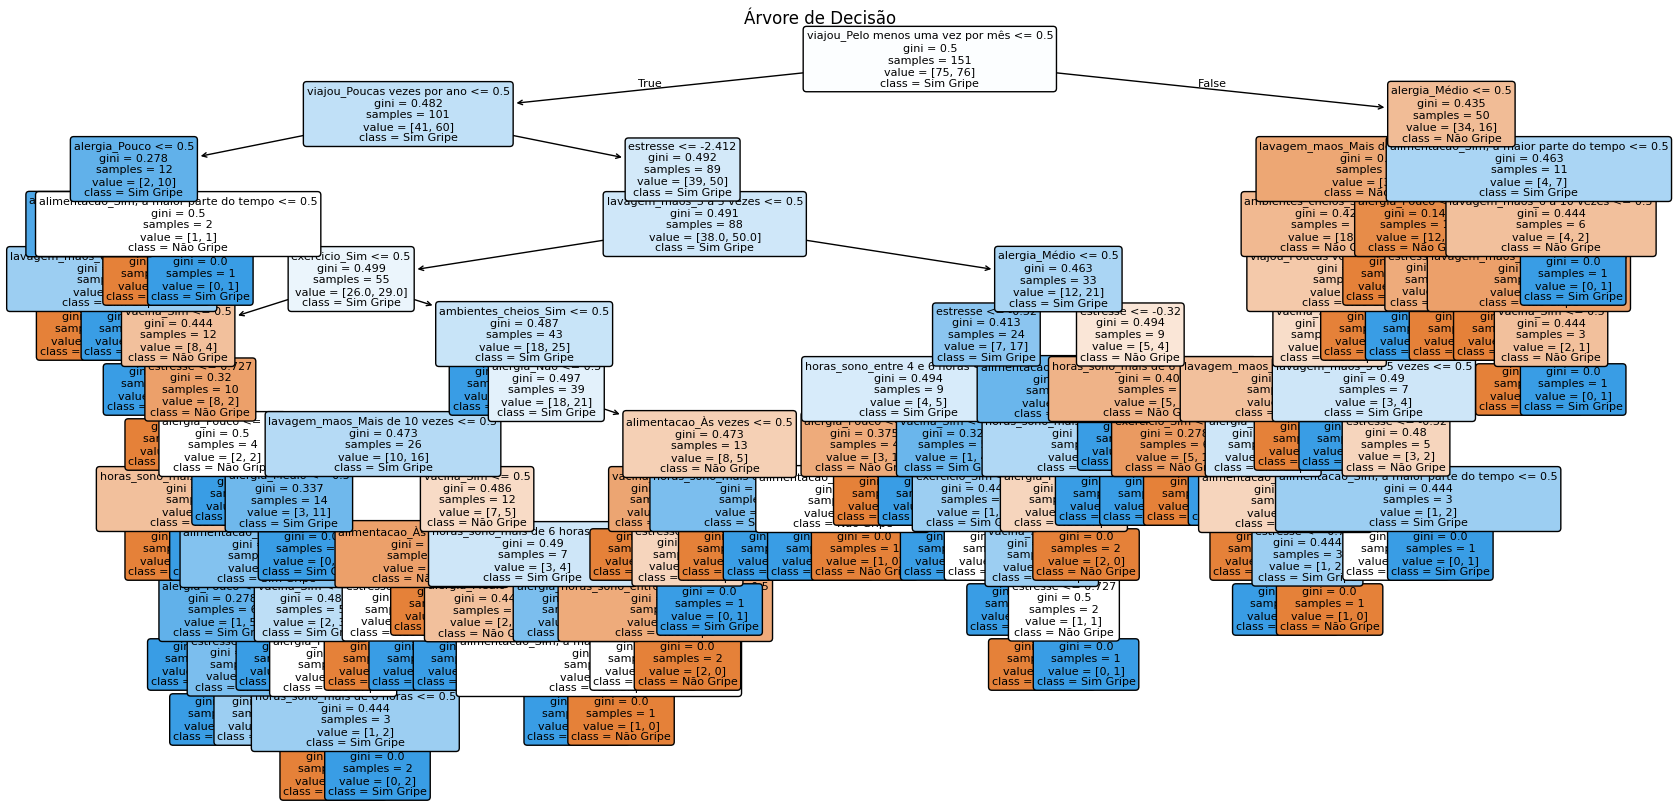


Acúrcia do Modelo na base de teste: 0.6462

Importância das Features:


,0
estresse,0.155482
horas_sono_mais de 6 horas,0.102614
vacina_Sim,0.091111
alergia_Médio,0.082700
alimentacao_Às vezes,0.078079
viajou_Pelo menos uma vez por mês,0.070596
"alimentacao_Sim, a maior parte do tempo",0.066854
alergia_Pouco,0.062478
lavagem_maos_6 a 10 vezes,0.060491
exercicio_Sim,0.044329


In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Visualizar a Árvore de Decisão
print("Visualizando a Árvore de Decisão (pode demorar um pouco para renderizar):")
plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=X_train.columns.tolist(), class_names=['Não Gripe', 'Sim Gripe'], filled=True, rounded=True, fontsize=8)
plt.title("Árvore de Decisão");
plt.show()

# 2. Avaliar a Acúrcia do Modelo
y_pred = dtc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcúrcia do Modelo na base de teste: {accuracy:.4f}")

# 3. Identificar as Colunas Mais Importantes
feature_importances = pd.Series(dtc.feature_importances_, index=X_train.columns)
print("\nImportância das Features:")
display(feature_importances.sort_values(ascending=False))